In [1]:
import sys
sys.path.append("../../src/")

import uncertainpy.gradual as grad  

# Higher-order example

In the following, we implement the following Higher-order QBAG.


<div>
<img src="pics/ho_bag_example.png" width="400"/>
</div>

### 1. Create HO-BAG

We can define
- initial weights for arguments, attacks and supports
- attackers and supporters of arguments, attacks and supports (only arguments can be the sources of attacks and supports)

In [2]:


model = grad.semantics.ContinuousDFQuADModel()
BAG = grad.BAG()

a_inn = grad.Argument("Innocent", 0.5)
a_gui = grad.Argument("Guilty", 0.5)

a_e1 = grad.Argument("E1", 0.7)
a_e2 = grad.Argument("E2", 0.8)
a_e3 = grad.Argument("E3", 0.4)
a_e4 = grad.Argument("E4", 0.1)
a_e5 = grad.Argument("E5", 0.6)

BAG.add_attack(a_inn, a_gui)
BAG.add_attack(a_gui, a_inn)

BAG.add_support(a_e1, a_inn)
sup_e2_guilty = BAG.add_support(a_e2, a_gui, 0.8)

BAG.add_attack(a_e3, a_e1, 0.6)
BAG.add_attack(a_e4, sup_e2_guilty, 0.7)
BAG.add_attack(a_e5, a_e2)


Att(E5, E2):1->1

### 2. Set up inference algorithm (approximator)

In [3]:
DELTA = 10e-2
EPSILON = 10e-4
N = 10

model.approximator = grad.algorithms.RK4(model)
model.BAG = BAG
result = model.solve(DELTA, EPSILON, True, True)


ContinuousDFQuADModel, RK4
Time: 9.799999999999981
Arg(Innocent):0.5->0.607
Arg(Guilty):0.5->0.317
Att(Innocent, Guilty):1->1.0
Att(Guilty, Innocent):1->1.0
Arg(E1):0.7->0.532
Sup(E1, Innocent):1->1.0
Arg(E2):0.8->0.32
Sup(E2, Guilty):0.8->0.744
Arg(E3):0.4->0.4
Att(E3, E1):0.6->0.6
Arg(E4):0.1->0.1
Att(E4, Sup(Arg(E2):0.8->0.8,Arg(Guilty):0.5->0.5)):0.7->0.7
Arg(E5):0.6->0.6
Att(E5, E2):1->1.0



### 3. Plot evolution of strength values

Only the strength values of arguments and those of relations that are being attacked or supported will be plotted.

{Arg(Innocent):0.5->0.607: [(0, 0.5), (0.1, 0.5089796355716667), (0.2, 0.516190945070226), (0.30000000000000004, 0.5219875800062187), (0.4, 0.5266601058082613), (0.5, 0.5304464219349936), (0.6, 0.5335405341541795), (0.7, 0.5360999338414966), (0.7999999999999999, 0.5382518000796086), (0.8999999999999999, 0.5400982072575491), (0.9999999999999999, 0.5417204928566933), (1.0999999999999999, 0.5431829163822628), (1.2, 0.5445357202994294), (1.3, 0.5458176868039528), (1.4000000000000001, 0.5470582698283902), (1.5000000000000002, 0.5482793694584355), (1.6000000000000003, 0.5494968055733738), (1.7000000000000004, 0.5507215387452453), (1.8000000000000005, 0.5519606789920646), (1.9000000000000006, 0.553218316677253), (2.0000000000000004, 0.554496204507443), (2.1000000000000005, 0.5557943150575148), (2.2000000000000006, 0.5571112944210042), (2.3000000000000007, 0.5584448293406249), (2.400000000000001, 0.5597919424283472), (2.500000000000001, 0.5611492277615783), (2.600000000000001, 0.56251303717731

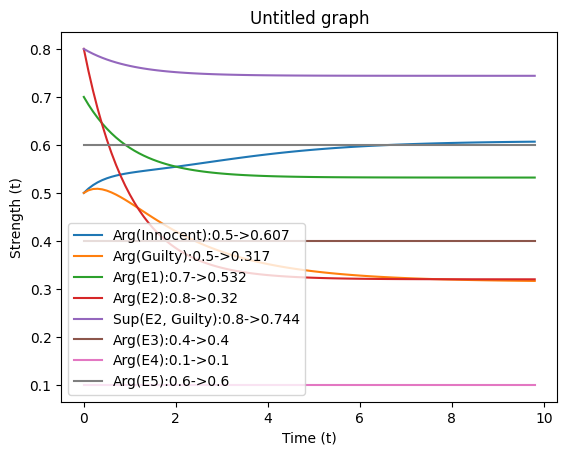

In [4]:
plot = grad.plotting.strengthplot(model, DELTA, EPSILON)
plot.show()